# Proyecto Final – Data Mining (PBL)
## Semana 1: Exploración Profunda y Formulación del Problema

**Curso:** CC3074 – Minería de Datos  
**Semestre:** I – 2026  
**Dataset:** Personas usuarias de Internet por grupo etario, países seleccionados, América Latina y el Caribe, 2000–2022  
**Fuente:** CEPAL – Statistics Portal

---
## 1. Importación de librerías

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

print(f"Polars version: {pl.__version__}")
print(f"Pandas version: {pd.__version__}")

Polars version: 1.39.3
Pandas version: 3.0.2


---
## 2. Carga del conjunto de datos

El dataset proviene de CEPAL Databank en formato Excel (.xlsx) con múltiples hojas. La hoja principal de interés es `datos`. Se carga con Pandas para manejo de tipos mixtos y luego se convierte a un DataFrame de Polars para el análisis.

In [2]:
# Carga con pandas (manejo de tipos Excel) → conversión a Polars
pdf = pd.read_excel("data_1777144519.xlsx", sheet_name="datos")

# Limpieza de tipos antes de convertir
pdf["Años__ESTANDAR"] = pd.to_numeric(pdf["Años__ESTANDAR"], errors='coerce').astype("Int64")
pdf["value"]          = pd.to_numeric(pdf["value"], errors='coerce')
pdf["source_id"]      = pdf["source_id"].astype(str)

df = pl.from_pandas(
    pdf.astype({"Años__ESTANDAR": "int64", "value": "float64"})
)

print("Dataset cargado exitosamente.")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset cargado exitosamente.
Dimensiones: 870 filas × 8 columnas


---
## 3. Inspección inicial del dataset

### 3.1 Esquema y primeras filas

In [3]:
print("Esquema (columnas y tipos):")
for col, dtype in df.schema.items():
    print(f"  {col:40s} → {dtype}")

Esquema (columnas y tipos):
  indicator                                → String
  País__ESTANDAR                           → String
  Grupos etarios Uso Internet              → String
  Años__ESTANDAR                           → Int64
  value                                    → Float64
  unit                                     → String
  notes_ids                                → Float64
  source_id                                → String


In [4]:
df.head(8)

indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
str,str,str,i64,f64,str,f64,str
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2016,75.9,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2017,75.9,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2018,78.5,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2019,78.9,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2020,87.5,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2021,86.9,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""edad de medicion a 17 años""",2022,86.5,"""Porcentaje sobre el total de p…",null,"""9353"""
"""Personas usuarias de Internet …","""Argentina""","""18 a 25 años de edad""",2016,86.4,"""Porcentaje sobre el total de p…",null,"""9353"""


### 3.2 Valores únicos de variables categóricas clave

In [5]:
countries = sorted(df["País__ESTANDAR"].unique().to_list())
age_groups = sorted(df["Grupos etarios Uso Internet"].unique().to_list())
years = sorted(df["Años__ESTANDAR"].unique().to_list())

print(f"Países ({len(countries)}):")
for c in countries:
    print(f"  - {c}")

print(f"\nGrupos etarios ({len(age_groups)}):")
for a in age_groups:
    print(f"  - {a}")

print(f"\nAños: {years[0]} – {years[-1]}  ({len(years)} valores distintos)")

Países (14):
  - Argentina
  - Bolivia (Estado Plurinacional de)
  - Brasil
  - Chile
  - Colombia
  - Costa Rica
  - Ecuador
  - El Salvador
  - Honduras
  - México
  - Panamá
  - Paraguay
  - Perú
  - Uruguay

Grupos etarios (6):
  - 18 a 25 años de edad
  - 26 a 50 años de edad
  - 51 a 65 años
  - 66 años en adelante
  - Total
  - edad de medicion a 17 años

Años: 2000 – 2022  (21 valores distintos)


### 3.3 Valores nulos

In [6]:
print("Conteo de valores nulos por columna:")
print(df.null_count())

print("\nObservación: La columna 'notes_ids' es completamente nula.")
print("La columna 'indicator' contiene un único valor constante:")
print(" ", df["indicator"].unique().to_list()[0][:80], "...")

Conteo de valores nulos por columna:
shape: (1, 8)
┌───────────┬───────────────┬───────────────┬───────────────┬───────┬──────┬───────────┬───────────┐
│ indicator ┆ País__ESTANDA ┆ Grupos        ┆ Años__ESTANDA ┆ value ┆ unit ┆ notes_ids ┆ source_id │
│ ---       ┆ R             ┆ etarios Uso   ┆ R             ┆ ---   ┆ ---  ┆ ---       ┆ ---       │
│ u32       ┆ ---           ┆ Internet      ┆ ---           ┆ u32   ┆ u32  ┆ u32       ┆ u32       │
│           ┆ u32           ┆ ---           ┆ u32           ┆       ┆      ┆           ┆           │
│           ┆               ┆ u32           ┆               ┆       ┆      ┆           ┆           │
╞═══════════╪═══════════════╪═══════════════╪═══════════════╪═══════╪══════╪═══════════╪═══════════╡
│ 0         ┆ 0             ┆ 0             ┆ 0             ┆ 0     ┆ 0    ┆ 870       ┆ 0         │
└───────────┴───────────────┴───────────────┴───────────────┴───────┴──────┴───────────┴───────────┘

Observación: La columna 'notes_ids' es 

---
## 4. Estadísticas descriptivas

La variable de interés es `value`: porcentaje de personas usuarias de Internet en cada grupo etario, por país y año.

In [7]:
print("Estadísticas descriptivas de 'value' (todas las observaciones):")
print(df.select("value").describe())

Estadísticas descriptivas de 'value' (todas las observaciones):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 870.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 44.813103 │
│ std        ┆ 27.810859 │
│ min        ┆ 0.2       │
│ 25%        ┆ 19.3      │
│ 50%        ┆ 45.2      │
│ 75%        ┆ 69.1      │
│ max        ┆ 96.8      │
└────────────┴───────────┘


In [8]:
# Estadísticas por grupo etario (excluyendo Total)
no_total = df.filter(pl.col("Grupos etarios Uso Internet") != "Total")

stats_por_grupo = (
    no_total
    .group_by("Grupos etarios Uso Internet")
    .agg([
        pl.col("value").mean().alias("media"),
        pl.col("value").std().alias("desv_std"),
        pl.col("value").min().alias("min"),
        pl.col("value").max().alias("max"),
        pl.len().alias("n_obs")
    ])
    .sort("media", descending=False)
)

print("Estadísticas por grupo etario:")
print(stats_por_grupo)

Estadísticas por grupo etario:
shape: (5, 6)
┌─────────────────────────────┬───────────┬───────────┬─────┬──────┬───────┐
│ Grupos etarios Uso Internet ┆ media     ┆ desv_std  ┆ min ┆ max  ┆ n_obs │
│ ---                         ┆ ---       ┆ ---       ┆ --- ┆ ---  ┆ ---   │
│ str                         ┆ f64       ┆ f64       ┆ f64 ┆ f64  ┆ u32   │
╞═════════════════════════════╪═══════════╪═══════════╪═════╪══════╪═══════╡
│ 66 años en adelante         ┆ 14.457931 ┆ 15.133786 ┆ 0.2 ┆ 62.7 ┆ 145   │
│ 51 a 65 años                ┆ 32.91931  ┆ 23.174538 ┆ 2.1 ┆ 88.4 ┆ 145   │
│ 26 a 50 años de edad        ┆ 52.002759 ┆ 25.83858  ┆ 4.4 ┆ 95.2 ┆ 145   │
│ edad de medicion a 17 años  ┆ 54.337931 ┆ 23.010659 ┆ 4.4 ┆ 90.9 ┆ 145   │
│ 18 a 25 años de edad        ┆ 66.833793 ┆ 22.924266 ┆ 8.6 ┆ 96.8 ┆ 145   │
└─────────────────────────────┴───────────┴───────────┴─────┴──────┴───────┘


In [9]:
# Cobertura temporal por país (usando solo fila 'Total')
total = df.filter(pl.col("Grupos etarios Uso Internet") == "Total")

cobertura = (
    total
    .group_by("País__ESTANDAR")
    .agg([
        pl.col("Años__ESTANDAR").min().alias("año_inicio"),
        pl.col("Años__ESTANDAR").max().alias("año_fin"),
        pl.len().alias("n_años_observados")
    ])
    .sort("País__ESTANDAR")
)

print("Cobertura temporal por país (grupo 'Total'):")
print(cobertura)

Cobertura temporal por país (grupo 'Total'):
shape: (14, 4)
┌─────────────────────────────────┬────────────┬─────────┬───────────────────┐
│ País__ESTANDAR                  ┆ año_inicio ┆ año_fin ┆ n_años_observados │
│ ---                             ┆ ---        ┆ ---     ┆ ---               │
│ str                             ┆ i64        ┆ i64     ┆ u32               │
╞═════════════════════════════════╪════════════╪═════════╪═══════════════════╡
│ Argentina                       ┆ 2016       ┆ 2022    ┆ 7                 │
│ Bolivia (Estado Plurinacional … ┆ 2009       ┆ 2021    ┆ 11                │
│ Brasil                          ┆ 2005       ┆ 2015    ┆ 8                 │
│ Chile                           ┆ 2000       ┆ 2017    ┆ 8                 │
│ Colombia                        ┆ 2012       ┆ 2022    ┆ 10                │
│ …                               ┆ …          ┆ …       ┆ …                 │
│ México                          ┆ 2015       ┆ 2022    ┆ 8           

---
## 5. Análisis exploratorio visual

### 5.1 Evolución temporal del uso total de Internet por país

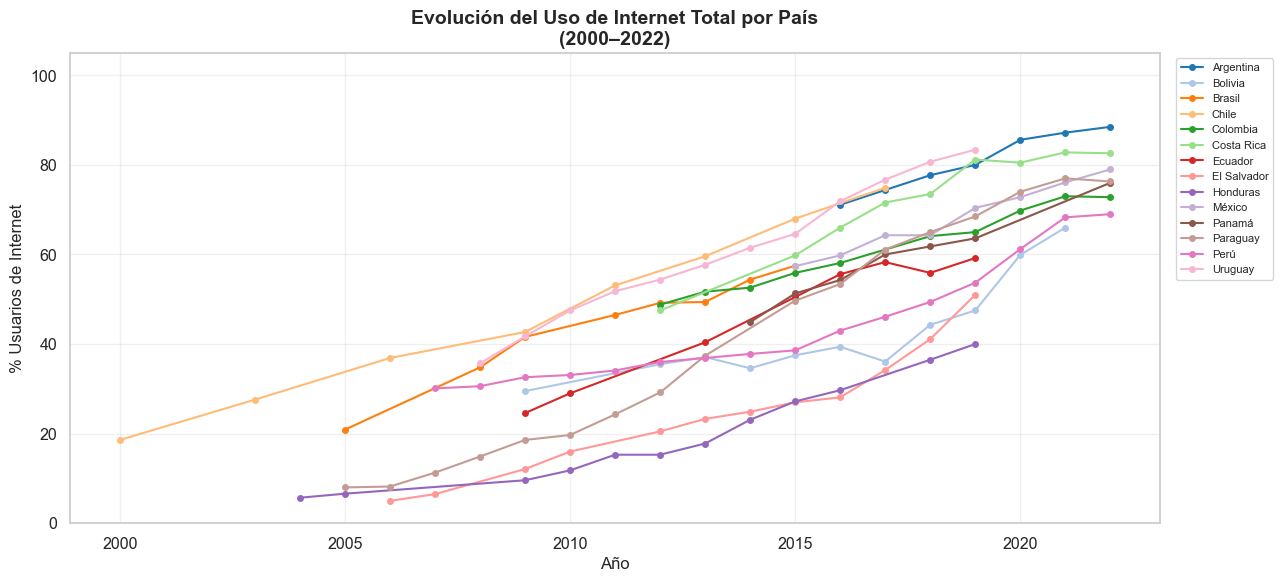

In [10]:
palette = plt.cm.tab20.colors
countries_list = sorted(total["País__ESTANDAR"].unique().to_list())

fig, ax = plt.subplots(figsize=(13, 6))

for i, country in enumerate(countries_list):
    g = total.filter(pl.col("País__ESTANDAR") == country).sort("Años__ESTANDAR")
    label = country.replace("Bolivia (Estado Plurinacional de)", "Bolivia")
    ax.plot(
        g["Años__ESTANDAR"].to_list(),
        g["value"].to_list(),
        marker='o', markersize=4,
        color=palette[i % len(palette)],
        label=label
    )

ax.set_title("Evolución del Uso de Internet Total por País\n(2000–2022)", fontsize=14, fontweight='bold')
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("% Usuarios de Internet", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa una tendencia de crecimiento generalizada a lo largo del tiempo en todos los países. Sin embargo, existen diferencias marcadas en el punto de partida (Chile inicia en 2000 con datos, mientras Argentina solo reporta desde 2016) y en el ritmo de crecimiento. Uruguay, Chile y Argentina muestran las tasas más altas, mientras Honduras y Bolivia presentan los valores más bajos al final del periodo.

### 5.2 Distribución del uso de Internet por grupo etario

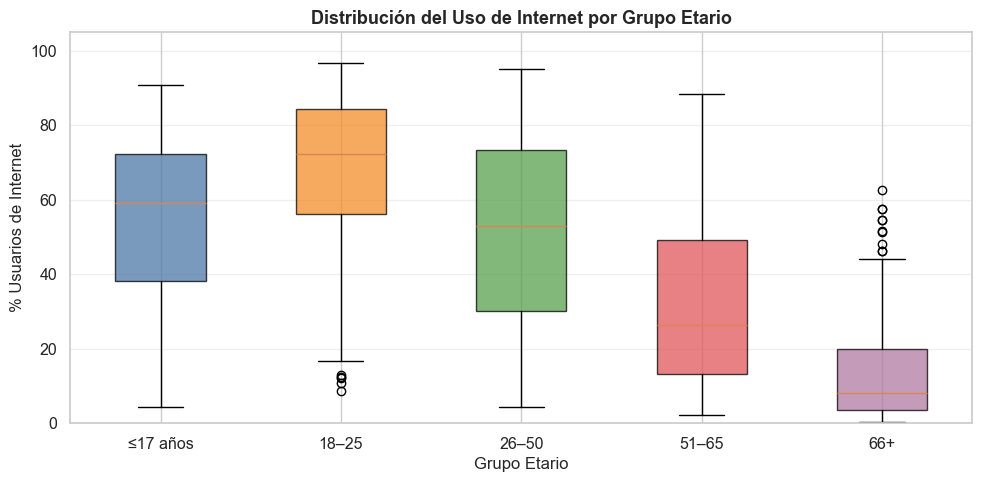

In [11]:
order_keys = [
    "edad de medicion a 17 años",
    "18 a 25 años de edad",
    "26 a 50 años de edad",
    "51 a 65 años",
    "66 años en adelante"
]
labels_short = ["≤17 años", "18–25", "26–50", "51–65", "66+"]
colors_box = ['#4e79a7','#f28e2b','#59a14f','#e15759','#b07aa1']

data_by_age = [
    no_total.filter(pl.col("Grupos etarios Uso Internet") == g)["value"].to_list()
    for g in order_keys
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_age, labels=labels_short, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title("Distribución del Uso de Internet por Grupo Etario", fontsize=13, fontweight='bold')
ax.set_ylabel("% Usuarios de Internet", fontsize=12)
ax.set_xlabel("Grupo Etario", fontsize=12)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Interpretación:** La brecha digital por edad es visible y sistemática. Los jóvenes (18–25 años) tienen la mediana más alta y poca dispersión. La adopción cae significativamente para el grupo de 51–65 años y de forma drástica para 66+ años. La dispersión es mayor en los grupos mayores, lo que sugiere que algunos países han avanzado más en inclusión digital de adultos mayores que otros.

### 5.3 Mapa de calor: promedio de uso de Internet por país y grupo etario

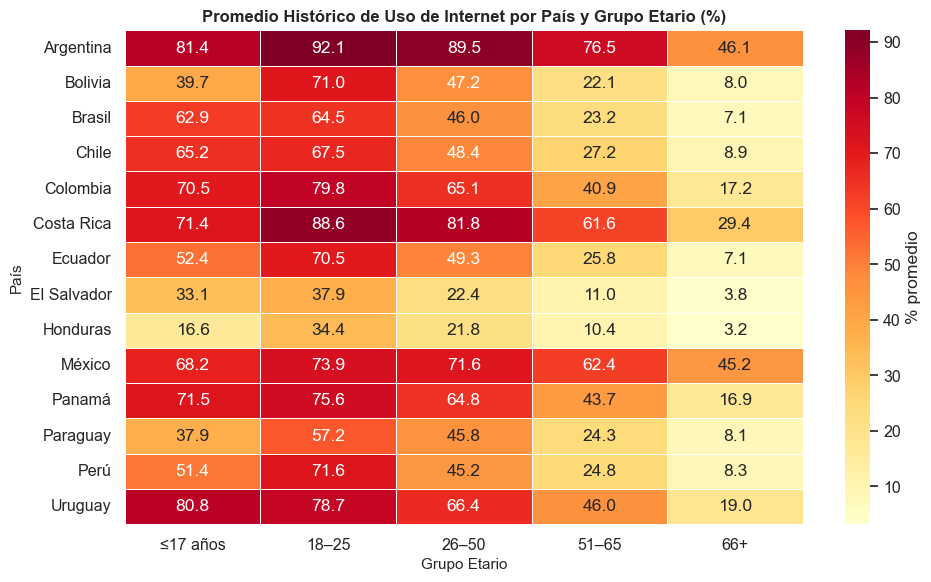

In [12]:
no_total_pdf = no_total.to_pandas()

pivot = (
    no_total_pdf
    .groupby(["País__ESTANDAR", "Grupos etarios Uso Internet"])["value"]
    .mean()
    .unstack()
    .reindex(columns=order_keys)
)
pivot.columns = labels_short
pivot.index = [
    c.replace("Bolivia (Estado Plurinacional de)", "Bolivia")
    for c in pivot.index
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot, annot=True, fmt=".1f",
    cmap="YlOrRd", ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={"label": "% promedio"}
)
ax.set_title("Promedio Histórico de Uso de Internet por País y Grupo Etario (%)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Grupo Etario", fontsize=11)
ax.set_ylabel("País", fontsize=11)
plt.tight_layout()
plt.show()

**Interpretación:** El mapa de calor evidencia perfiles diferenciados entre países. Argentina, Uruguay y Chile muestran valores altos en todos los grupos etarios. Honduras, Paraguay y Bolivia presentan los valores más bajos, especialmente en adultos mayores. Este patrón de agrupamiento natural sugiere que un enfoque de clustering por perfil etario es apropiado para este dataset.

### 5.4 Cobertura temporal por país (análisis de datos faltantes estructurales)

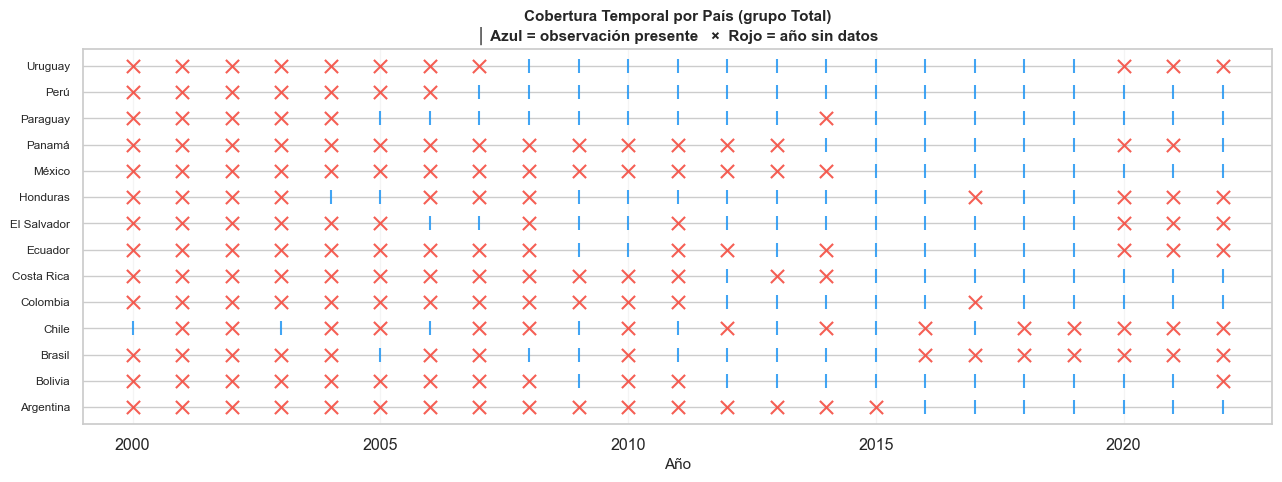

In [13]:
all_years_range = list(range(2000, 2023))
countries_sorted = sorted(df["País__ESTANDAR"].unique().to_list())

fig, ax = plt.subplots(figsize=(13, 5))

for i, country in enumerate(countries_sorted):
    c_years = set(
        total.filter(pl.col("País__ESTANDAR") == country)["Años__ESTANDAR"].to_list()
    )
    for y in all_years_range:
        color  = '#2196F3' if y in c_years else '#F44336'
        marker = '|'       if y in c_years else 'x'
        ax.scatter(y, i, marker=marker, s=90, color=color, alpha=0.85, linewidths=1.5)

ax.set_yticks(range(len(countries_sorted)))
ax.set_yticklabels(
    [c.replace("Bolivia (Estado Plurinacional de)", "Bolivia") for c in countries_sorted],
    fontsize=8.5
)
ax.set_xlabel("Año", fontsize=11)
ax.set_title(
    "Cobertura Temporal por País (grupo Total)\n"
    "│ Azul = observación presente   ×  Rojo = año sin datos",
    fontsize=11, fontweight='bold'
)
ax.grid(True, alpha=0.2, axis='x')
ax.set_xlim(1999, 2023)
plt.tight_layout()
plt.show()

**Interpretación:** El dataset presenta un **panel de datos no balanceado**. Ningún país tiene observaciones continuas para todos los años 2000–2022. Paraguay y Perú tienen la mayor cobertura (17 y 16 años), mientras Argentina y Panamá solo cuentan con 7. Además, los años disponibles por país no son consecutivos en todos los casos, lo que representa un problema de datos estructural que debe abordarse en la fase de transformación.

---
## 6. Identificación de problemas en los datos

### 6.1 Resumen de problemas detectados

In [14]:
# Panel no balanceado: conteo de años por país
años_por_pais = (
    total
    .group_by("País__ESTANDAR")
    .agg(pl.len().alias("n_años_observados"))
    .sort("n_años_observados")
)

print("Número de observaciones (Total) por país:")
print(años_por_pais)

print(f"\nDiferencia entre máximo y mínimo de observaciones: "
      f"{años_por_pais['n_años_observados'].max() - años_por_pais['n_años_observados'].min()}")

Número de observaciones (Total) por país:
shape: (14, 2)
┌────────────────┬───────────────────┐
│ País__ESTANDAR ┆ n_años_observados │
│ ---            ┆ ---               │
│ str            ┆ u32               │
╞════════════════╪═══════════════════╡
│ Panamá         ┆ 7                 │
│ Argentina      ┆ 7                 │
│ Brasil         ┆ 8                 │
│ Ecuador        ┆ 8                 │
│ México         ┆ 8                 │
│ …              ┆ …                 │
│ Uruguay        ┆ 12                │
│ Honduras       ┆ 12                │
│ El Salvador    ┆ 12                │
│ Perú           ┆ 16                │
│ Paraguay       ┆ 17                │
└────────────────┴───────────────────┘

Diferencia entre máximo y mínimo de observaciones: 10


In [15]:
# Columnas con valor constante o inútil para modelado
print("Columnas con un único valor (constantes):")
for col in df.columns:
    n_unique = df[col].n_unique()
    if n_unique == 1:
        print(f"  - '{col}' → valor único: {df[col][0]}")

print("\nColumnas completamente nulas:")
nulls = df.null_count()
for col in df.columns:
    n = nulls[col][0]
    if n == df.shape[0]:
        print(f"  - '{col}' → {n} valores nulos ({100}%)")

Columnas con un único valor (constantes):
  - 'indicator' → valor único: Personas usuarias de Internet por grupo etario, países seleccionados América Latina y el Caribe, 2000 a 2022
  - 'unit' → valor único: Porcentaje sobre el total de personas en cada grupo etario
  - 'notes_ids' → valor único: None
  - 'source_id' → valor único: 9353

Columnas completamente nulas:
  - 'notes_ids' → 870 valores nulos (100%)


In [16]:
# Cobertura de años por grupo etario por país (¿hay grupos etarios sin datos en ciertos países/años?)
cobertura_etaria = (
    no_total
    .group_by(["País__ESTANDAR", "Grupos etarios Uso Internet"])
    .agg(pl.len().alias("n_obs"))
    .sort(["País__ESTANDAR", "n_obs"])
)

print("Observaciones por país y grupo etario:")
print(cobertura_etaria.head(20))

# Verificar si todos los pares país-año tienen los 5 grupos etarios
n_grupos_por_pais_anio = (
    no_total
    .group_by(["País__ESTANDAR", "Años__ESTANDAR"])
    .agg(pl.n_unique("Grupos etarios Uso Internet").alias("n_grupos"))
    .filter(pl.col("n_grupos") < 5)
)

print(f"\nPares (país, año) con menos de 5 grupos etarios reportados: {len(n_grupos_por_pais_anio)}")
if len(n_grupos_por_pais_anio) > 0:
    print(n_grupos_por_pais_anio)

Observaciones por país y grupo etario:
shape: (20, 3)
┌────────────────┬─────────────────────────────┬───────┐
│ País__ESTANDAR ┆ Grupos etarios Uso Internet ┆ n_obs │
│ ---            ┆ ---                         ┆ ---   │
│ str            ┆ str                         ┆ u32   │
╞════════════════╪═════════════════════════════╪═══════╡
│ Argentina      ┆ 18 a 25 años de edad        ┆ 7     │
│ Argentina      ┆ edad de medicion a 17 años  ┆ 7     │
│ Argentina      ┆ 26 a 50 años de edad        ┆ 7     │
│ Argentina      ┆ 66 años en adelante         ┆ 7     │
│ Argentina      ┆ 51 a 65 años                ┆ 7     │
│ …              ┆ …                           ┆ …     │
│ Chile          ┆ 18 a 25 años de edad        ┆ 8     │
│ Chile          ┆ 51 a 65 años                ┆ 8     │
│ Chile          ┆ 66 años en adelante         ┆ 8     │
│ Chile          ┆ edad de medicion a 17 años  ┆ 8     │
│ Chile          ┆ 26 a 50 años de edad        ┆ 8     │
└────────────────┴────────────────

In [ ]:
# Distribución de floats con imprecisiones (ej. 86.90000000000001)
# Verificar rango de valores
print("Valores fuera del rango esperado [0, 100]:")
fuera_rango = df.filter((pl.col("value") < 0) | (pl.col("value") > 100))
print(f"  {len(fuera_rango)} filas fuera de rango")

print("\nEjemplos de imprecisiones flotantes (valores > .5 decimal):")
imprecisiones = df.filter(
    (pl.col("value") - pl.col("value").round(1)).abs() > 0.001
)
print(f"  Filas con imprecisión flotante: {len(imprecisiones)}")
print(imprecisiones.select(["País__ESTANDAR", "Años__ESTANDAR", "value"]).head(5))

### 6.2 Resumen consolidado de problemas identificados

| # | Problema | Descripción | Impacto |
|---|---------|-------------|----------|
| 1 | **Panel no balanceado** | Los países tienen distintas cantidades de años observados (7 a 17), y los años no son consecutivos para todos | Impide comparación directa entre países sin transformación |
| 2 | **Columnas irrelevantes** | `indicator` es constante, `notes_ids` es 100% nula, `source_id` es metadato | Deben eliminarse antes del modelado |
| 3 | **Formato largo (long format)** | El dataset está en formato largo: una fila por (país, grupo etario, año). No es utilizable directamente por algoritmos de ML | Requiere transformación pivot |
| 4 | **Imprecisiones flotantes** | Valores como `86.90000000000001` por representación IEEE 754 | Deben redondearse a 1 decimal |
| 5 | **Mezcla de categoría 'Total'** | La fila `Total` es un agregado de los demás grupos, no una categoría independiente | Debe separarse o manejarse explícitamente |
| 6 | **Inconsistencia de cobertura temporal** | No todos los años 2000–2022 están presentes para todos los países | Estrategia de imputación o selección de subconjunto de años necesaria |

---
## 7. Formulación de problemas potenciales

### Problema 1 – Clustering: Perfiles de inclusión digital por país

**Formulación:** Agrupar los 14 países latinoamericanos según su perfil promedio de adopción de Internet por grupo etario, identificando arquetipos de inclusión digital.

**Variable objetivo:** No aplica (aprendizaje no supervisado).

**Transformación requerida:** Pivot de formato largo a formato ancho, donde cada fila es un país y las columnas son los 5 grupos etarios (promedio histórico o año específico).

**Técnicas candidatas:** K-Means, Hierarchical Clustering, K-Means++.

---

### Problema 2 – Regresión: Predicción de la tasa de adopción futura

**Formulación:** Predecir el porcentaje de uso total de Internet para un país dado en un año futuro, basándose en sus patrones históricos.

**Variable objetivo:** `value` (columna numérica continua, porcentaje).

**Transformación requerida:** Filtrar a filas 'Total', codificar país como variable categórica, usar año como variable numérica predictora (y opcionalmente lag features).

**Técnicas candidatas:** Regresión lineal múltiple, SVR, Árbol de decisión para regresión.

---

### 7.1 Problema seleccionado: Clustering de países por perfil de inclusión digital

**Justificación:**

1. **Naturaleza del dataset:** El dataset no tiene una variable objetivo definida naturalmente. La variable `value` es una medida descriptiva, no una etiqueta asignada externamente. El clustering es la opción más honesta con la estructura real de los datos.

2. **Relevancia de la pregunta:** ¿Qué países de Latinoamérica tienen perfiles similares de adopción digital por grupos de edad? Esta pregunta tiene valor analítico real para política pública y comparación regional.

3. **Transformación obligatoria:** El problema de clustering requiere pivotar el dataset de formato largo a ancho (una fila por país, columnas por grupo etario), cumpliendo la regla obligatoria del proyecto.

4. **Riqueza de comparación:** Se pueden comparar al menos 3 algoritmos de clustering (K-Means, K-Means++, Clustering Jerárquico) con métricas como el coeficiente de silhouette y el criterio del codo.

5. **Temas del curso:** El clustering fue uno de los primeros temas del curso y el dataset de países (`Paises_Mundo.csv`) usado en clase tiene estructura análoga a la transformación propuesta.

In [17]:
# Vista previa de la transformación para el problema seleccionado
order_keys = [
    "edad de medicion a 17 años",
    "18 a 25 años de edad",
    "26 a 50 años de edad",
    "51 a 65 años",
    "66 años en adelante"
]

pivot_preview = (
    no_total
    .group_by(["País__ESTANDAR", "Grupos etarios Uso Internet"])
    .agg(pl.col("value").mean().alias("uso_promedio"))
    .sort(["País__ESTANDAR", "Grupos etarios Uso Internet"])
    .to_pandas()
    .pivot_table(
        index="País__ESTANDAR",
        columns="Grupos etarios Uso Internet",
        values="uso_promedio"
    )
    .reindex(columns=order_keys)
)

pivot_preview.columns = ["≤17", "18-25", "26-50", "51-65", "66+"]
pivot_preview.index.name = "País"
pivot_preview = pivot_preview.round(1)

print("Vista previa del dataset transformado (formato para clustering):")
print(pivot_preview.to_string())

Vista previa del dataset transformado (formato para clustering):
                                    ≤17  18-25  26-50  51-65   66+
País                                                              
Argentina                          81.4   92.1   89.5   76.5  46.1
Bolivia (Estado Plurinacional de)  39.7   71.0   47.2   22.1   8.0
Brasil                             62.9   64.5   46.0   23.2   7.1
Chile                              65.2   67.4   48.4   27.2   8.9
Colombia                           70.5   79.8   65.1   40.9  17.2
Costa Rica                         71.4   88.6   81.8   61.6  29.4
Ecuador                            52.4   70.5   49.3   25.8   7.1
El Salvador                        33.1   37.9   22.4   11.0   3.8
Honduras                           16.6   34.4   21.8   10.4   3.2
México                             68.2   73.9   71.6   62.4  45.2
Panamá                             71.5   75.6   64.8   43.7  16.9
Paraguay                           37.9   57.2   45.8   24.3   8

---
## 8. Conclusiones de la Semana 1

El conjunto de datos de CEPAL contiene **870 observaciones** sobre el uso de Internet en 14 países latinoamericanos, desagregadas por 5 grupos etarios, con cobertura de 2000 a 2022. El dataset está en **formato largo** y presenta un **panel no balanceado** como problema estructural principal.

Se identificaron **6 problemas de datos** que deberán abordarse en la Semana 2. El problema seleccionado para el proyecto es **clustering de países por perfil de inclusión digital**, que requiere transformar el dataset a formato ancho y aplicará técnicas como K-Means, K-Means++ y clustering jerárquico comparados mediante el coeficiente de silhouette.